In [2]:
import pandas as pd

# Load the results file
results_file = "final_reversed_data_results.csv"
results_df = pd.read_csv(results_file)

# Group by 'Model Type' and 'File', and calculate averages
averaged_results_df = results_df.groupby(['Model Type', 'File'], as_index=False).agg({
    'MSE Score': 'mean',
    'MSE Raw Score': 'mean',
    'RMSE Score': 'mean',
    'Data Correlation': 'mean',
    'CV round': 'count'  # Count how many CV rounds were used for each file-model combination
})

# Rename 'CV round' to 'Number of CV Rounds'
averaged_results_df.rename(columns={'CV round': 'Number of CV Rounds'}, inplace=True)

# Display the averaged results
display(averaged_results_df)


,Model Type,File,MSE Score,MSE Raw Score,RMSE Score,Data Correlation,Number of CV Rounds
0,LightGBM,transformed_data__impute.csv,9.653066e+05,9.653066e+05,4.114931e+02,1.000000e+00,20
1,LightGBM,transformed_data__impute__adf.csv,1.174002e+10,1.180245e+10,3.578256e+04,2.974310e-01,20
2,LightGBM,transformed_data__impute__adf__log_all__local_...,3.658119e+08,2.090568e+10,8.390435e+03,8.178220e-02,20
3,LightGBM,transformed_data__impute__adf__log_all__soft_c...,4.709410e+162,6.729573e+81,5.115016e+80,-2.543040e-01,18
4,LightGBM,transformed_data__impute__adf__power__sliding_...,1.430255e+12,9.368434e+13,3.623075e+05,2.071544e-01,20
...,...,...,...,...,...,...,...
105,XGBoost,transformed_data__impute__scale__pct_change__r...,NaN,NaN,NaN,3.303213e-02,20
106,XGBoost,transformed_data__impute__scale__pct_change__s...,4.200995e+13,1.179940e+13,2.220154e+06,-2.007406e-02,20
107,XGBoost,transformed_data__impute__scale__power__slidin...,4.553440e+11,1.128104e+12,2.063529e+05,5.504105e-01,20
108,XGBoost,transformed_data__impute__scale__quantile__rel...,4.285493e+25,4.285488e+25,1.495004e+12,4.444871e-17,20


In [7]:
# Drop rows with NaN values in 'MSE Score' or 'MSE Raw Score'
cleaned_results_df = averaged_results_df.dropna(subset=['MSE Score', 'MSE Raw Score'])


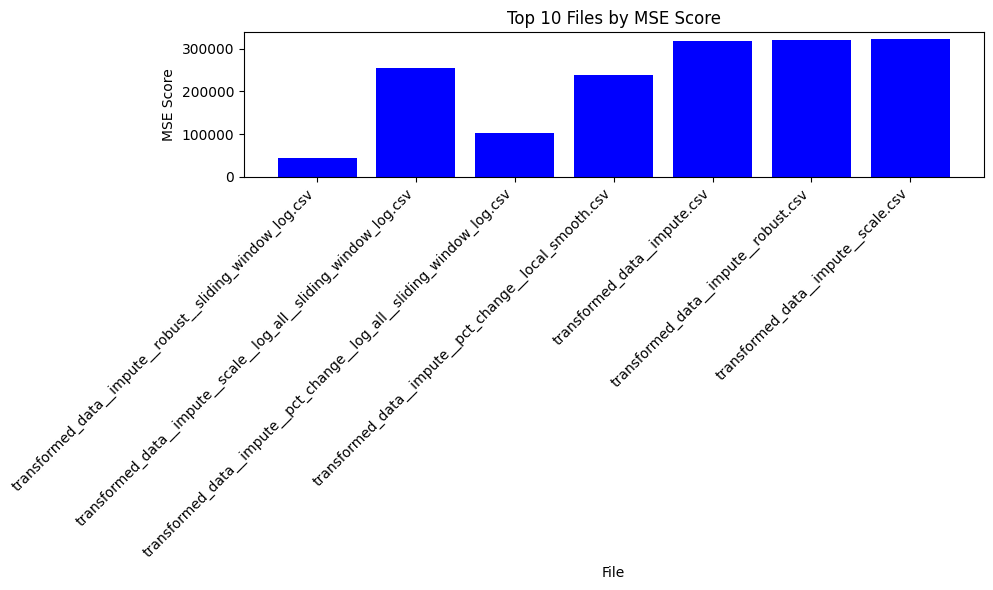

In [8]:
import matplotlib.pyplot as plt

# Sort by 'MSE Score' and select the top 10
top_10_mse = cleaned_results_df.sort_values(by='MSE Score').head(10)

# Create a barplot for 'MSE Score'
plt.figure(figsize=(10, 6))
plt.bar(top_10_mse['File'], top_10_mse['MSE Score'], color='blue')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Files by MSE Score')
plt.ylabel('MSE Score')
plt.xlabel('File')
plt.tight_layout()
plt.show()


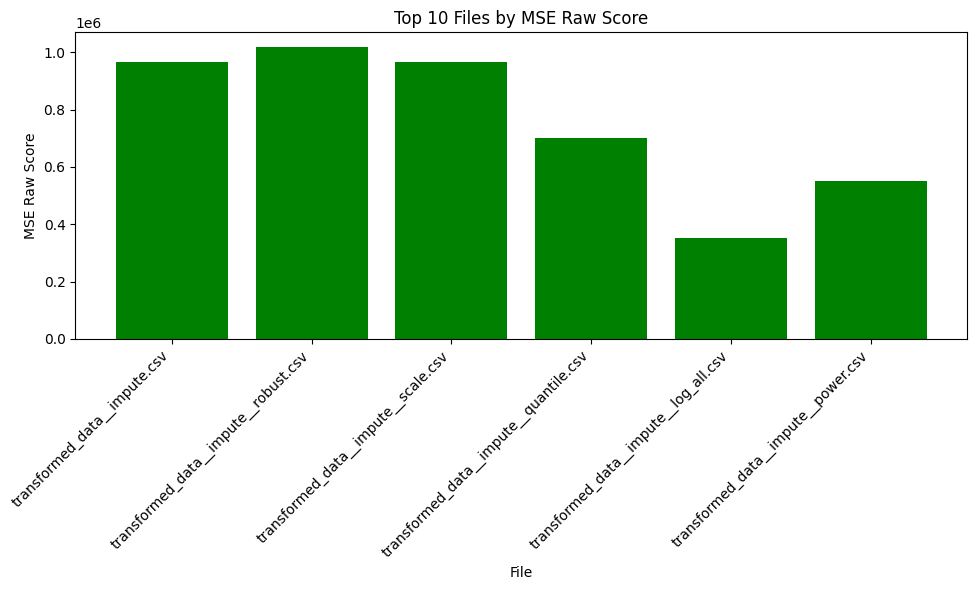

In [11]:
# Sort by 'MSE Raw Score' and select the top 10
top_10_mse_raw = cleaned_results_df.sort_values(by='MSE Raw Score').head(10)

# Create a barplot for 'MSE Raw Score'
plt.figure(figsize=(10, 6))
plt.bar(top_10_mse_raw['File'], top_10_mse_raw['MSE Raw Score'], color='green')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Files by MSE Raw Score')
plt.ylabel('MSE Raw Score')
plt.xlabel('File')
plt.tight_layout()
plt.show()


In [9]:
# Sort by 'MSE Score' and select the top 20
top_20_mse = cleaned_results_df.sort_values(by='MSE Score').head(20)

# Display the top 20 files by 'MSE Score'
display(top_20_mse)


,Model Type,File,MSE Score,MSE Raw Score,RMSE Score,Data Correlation,Number of CV Rounds
94,XGBoost,transformed_data__impute__robust__sliding_wind...,4.061628e+04,1.790474e+06,104.234106,0.599359,20
39,LightGBM,transformed_data__impute__robust__sliding_wind...,4.345675e+04,1.799878e+06,107.341250,0.599359,20
99,XGBoost,transformed_data__impute__scale__log_all__slid...,6.649026e+04,1.751492e+06,108.938062,0.362663,20
83,XGBoost,transformed_data__impute__pct_change__log_all_...,8.591306e+04,2.291947e+06,141.655738,0.187228,20
28,LightGBM,transformed_data__impute__pct_change__log_all_...,1.028109e+05,2.231580e+06,154.143632,0.187228,20
23,LightGBM,transformed_data__impute__pct_change__local_sm...,2.385145e+05,4.130513e+08,245.711231,0.305886,20
44,LightGBM,transformed_data__impute__scale__log_all__slid...,2.551816e+05,2.731923e+06,187.098025,0.362663,20
55,XGBoost,transformed_data__impute.csv,3.190060e+05,3.190060e+05,263.455988,1.000000,20
90,XGBoost,transformed_data__impute__robust.csv,3.204252e+05,3.204252e+05,264.505362,1.000000,20
95,XGBoost,transformed_data__impute__scale.csv,3.221142e+05,3.221142e+05,265.568321,1.000000,20


C:\Users\nabounaser\AppData\Local\Temp\ipykernel_12012\2571874981.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_results_df['Aggregated Score'] = cleaned_results_df['MSE Score'] + cleaned_results_df['MSE Raw Score']


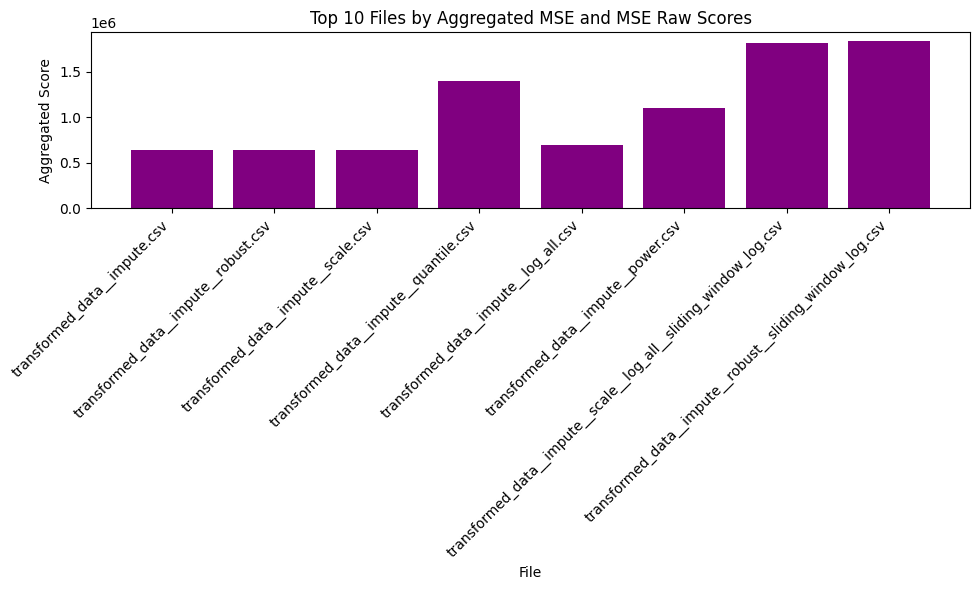

In [10]:
# Create a new column that aggregates MSE and MSE Raw scores
cleaned_results_df['Aggregated Score'] = cleaned_results_df['MSE Score'] + cleaned_results_df['MSE Raw Score']

# Sort by the aggregated score and select the top 10
top_10_aggregated = cleaned_results_df.sort_values(by='Aggregated Score').head(10)

# Create a barplot for aggregated scores
plt.figure(figsize=(10, 6))
plt.bar(top_10_aggregated['File'], top_10_aggregated['Aggregated Score'], color='purple')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Files by Aggregated MSE and MSE Raw Scores')
plt.ylabel('Aggregated Score')
plt.xlabel('File')
plt.tight_layout()
plt.show()


In [13]:
# print the average MSE Score across all files and all rows
print("Evaluating for the reversed dataset:")
average_mse = cleaned_results_df['MSE Score'].mean()
print(f"Average MSE Score: {average_mse}")
# print the average MSE Score across the top ten lowest/best mse scores
average_top_10_mse = top_10_mse['MSE Score'].mean()
print(f"Average MSE Score (Top 10): {average_top_10_mse}")

non_reversed_results = pd.read_csv("process_data_eval_without_reversal.csv",index_col='Date',parse_dates=True)


Average MSE Score: inf
Average MSE Score (Top 10): 179452.86608652398


In [ ]:
# Show bar plot of top ten results in terms of mse normal (not raw)

import matplotlib.pyplot as plt

# Sort the averaged results by 'MSE Score' in ascending order
sorted_averaged_results_df = averaged_results_df.sort_values(by=['MSE Score'])

# Get the top ten results